# An Initial Exploration of the Lorenz Attractor

We consider the Lorenz system $$\begin{align}\frac{dx}{dt} &= \sigma(y-x)\\\frac{dy}{dt} &= -xz + rx - y\\\frac{dz}{dt} &= xy - bz,\end{align}$$ with paramters $\sigma = 10$, $r = 28$, and $b=\frac{8}{3}$.

In [111]:
import numpy as np
import matplotlib.pyplot as plt

In [112]:
# runge-kutta fourth-order integrator
def rk4(f, t0, tf, x0, dt, substeps=4, f_args=()):
    t = np.arange(t0, tf + dt, dt)
    x = np.empty((t.size, len(x0)), dtype=float)
    x[0] = np.array(x0, dtype=float)
    h = dt / substeps

    # integrate
    for n in range(t.size - 1):
        tn = t[n]
        xn = x[n].copy()
        # internal substeps for stability/accuracy
        for _ in range(substeps):
            k1 = f(tn, xn, *f_args)
            k2 = f(tn + 0.5 * h, xn + 0.5 * h * k1, *f_args)
            k3 = f(tn + 0.5 * h, xn + 0.5 * h * k2, *f_args)
            k4 = f(tn + h, xn + h * k3, *f_args)
            xn = xn + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
            tn = tn + h
        x[n + 1] = xn

    return t, x

### Visualizing the attractor

In [113]:
# lorenz attractor eqns
def lorenz(t, x, sigma, r, b):
    dx_dt = sigma * (x[1] - x[0])
    dy_dt = x[0] * (r - x[2]) - x[1]
    dz_dt = x[0] * x[1] - b * x[2]
    return np.array([dx_dt, dy_dt, dz_dt], dtype=float)

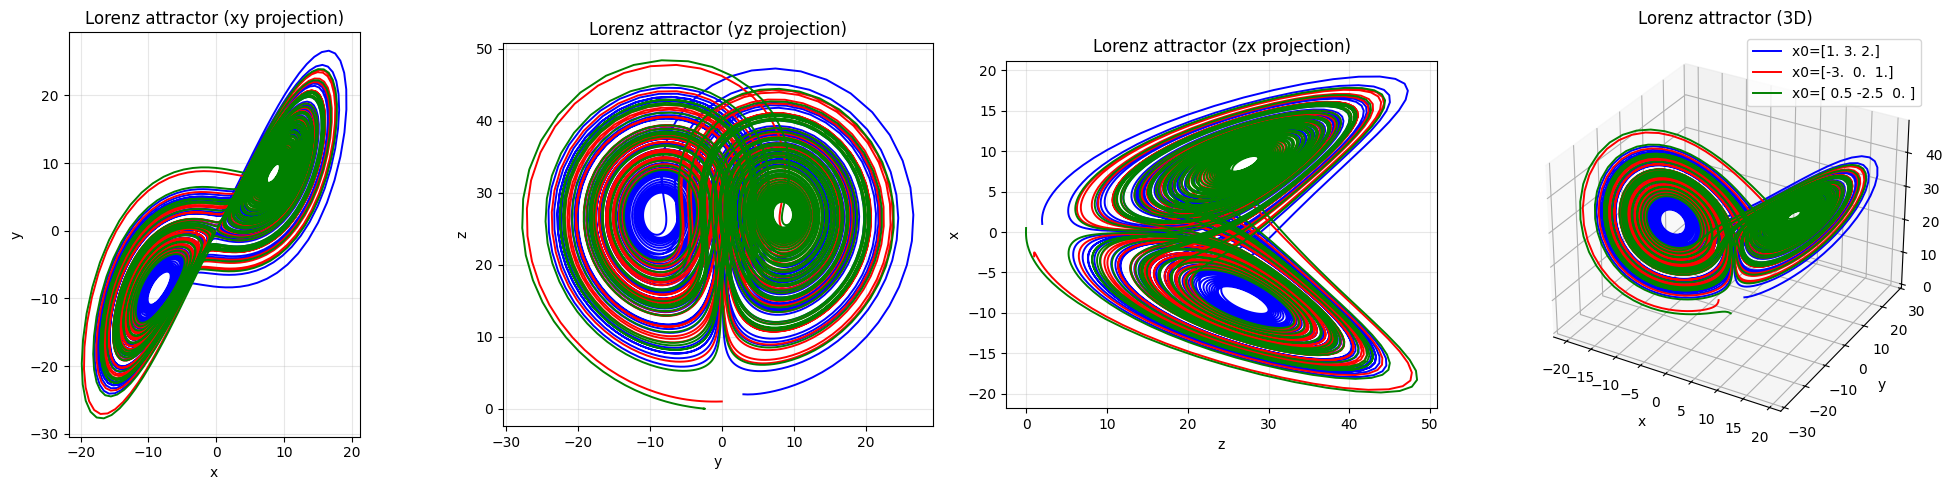

In [114]:
sigma, r, b = 10, 28, 8/3
t0, tf = 0.0, 50.0
dt = 0.01
x0s = [np.array([1.0, 3.0, 2.0]), np.array([-3.0, 0.0, 1.0]), np.array([0.5, -2.5, 0.0])]
colors = ['blue', 'red', 'green']

fig = plt.figure(figsize=(20, 5))
ax_xy = fig.add_subplot(1, 4, 1)
ax_yz = fig.add_subplot(1, 4, 2)
ax_zx = fig.add_subplot(1, 4, 3)
ax_3d = fig.add_subplot(1, 4, 4, projection='3d')

for x0, color in zip(x0s, colors):
    t, x = rk4(lorenz, t0, tf, x0, dt, f_args=(sigma, r, b))
    x_t = x[:, 0]
    y_t = x[:, 1]
    z_t = x[:, 2]

    ax_xy.plot(x_t, y_t, lw=1.4, color=color, label=f'x0={x0}')
    ax_yz.plot(y_t, z_t, lw=1.4, color=color, label=f'x0={x0}')
    ax_zx.plot(z_t, x_t, lw=1.4, color=color, label=f'x0={x0}')
    ax_3d.plot(x_t, y_t, z_t, lw=1.4, color=color, label=f'x0={x0}')

ax_xy.set_title('Lorenz attractor (xy projection)')
ax_xy.set_xlabel('x')
ax_xy.set_ylabel('y')
ax_xy.grid(alpha=0.3)
ax_xy.set_aspect('equal', adjustable='box')

ax_yz.set_title('Lorenz attractor (yz projection)')
ax_yz.set_xlabel('y')
ax_yz.set_ylabel('z')
ax_yz.grid(alpha=0.3)
ax_yz.set_aspect('equal', adjustable='box')

ax_zx.set_title('Lorenz attractor (zx projection)')
ax_zx.set_xlabel('z')
ax_zx.set_ylabel('x')
ax_zx.grid(alpha=0.3)
ax_zx.set_aspect('equal', adjustable='box')

ax_3d.set_title('Lorenz attractor (3D)')
ax_3d.set_xlabel('x')
ax_3d.set_ylabel('y')
ax_3d.set_zlabel('z')
ax_3d.grid(alpha=0.3)
ax_3d.legend()

plt.tight_layout()
plt.show()

### Testing deviation in initial conditions and solutions

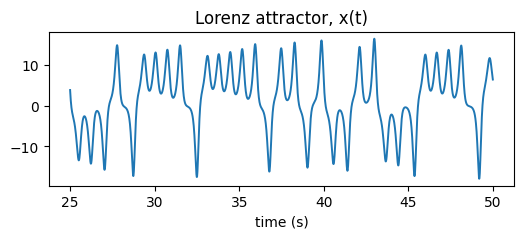

In [115]:
x0 = np.array([1.0, 3.0, 2.0])
t, x = rk4(lorenz, t0, tf, x0, dt, f_args=(sigma, r, b))
x_t = x[:, 0]
y_t = x[:, 1]
z_t = x[:, 2]
plt.figure(figsize=(6, 2))
ts = np.arange(2501) * 0.01 + 25
plt.plot(ts, x_t[2500:], lw=1.4)
plt.xlabel('time (s)')
plt.title('Lorenz attractor, x(t)')
plt.show()

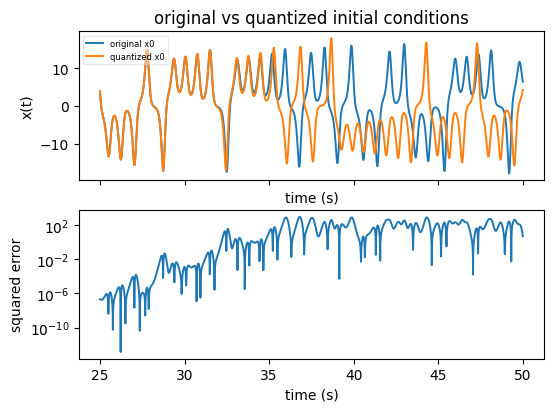

In [116]:
# quantizing initial condition at t = 25 sec to 3 decimal places
x0 = np.round(np.array([x_t[2500], y_t[2500], z_t[2500]]), decimals=3)
t, x = rk4(lorenz, 0, 25, x0, dt, f_args=(sigma, r, b))
x_tq = x[:, 0]
sq_err = (x_tq - x_t[2500:]) ** 2

fig, ax = plt.subplots(2, 1, figsize=(6, 4.25), sharex=True)
ax[0].plot(ts, x_t[2500:], lw=1.4, label=f'original x0')
ax[0].plot(ts, x_tq, lw=1.4, label=f'quantized x0')
ax[0].set_xlabel('time (s)')
ax[0].set_ylabel('x(t)')
ax[0].legend(loc='upper left', fontsize=6, framealpha=0.4)
ax[0].set_title('original vs quantized initial conditions')
ax[1].semilogy(ts, sq_err, lw=1.4)
ax[1].set_xlabel('time (s)')
ax[1].set_ylabel('squared error')
plt.show()

We can see above that the error increases over time and eventually saturates at the scale of the entire attractor (invariant) set, signifying a different trajectory of a chaotic system.

### Varying $r$: bifurcations and chaos

We can indeed see a similar period doubling route to chaos over $99 < r < 100$, with suggested chaos at both extremes.

In [117]:
def local_maxima(z): # z being a subsection of z(t) part of the trajectory
    # interior points where z[i] > neighbors
    idx = np.where((z[1:-1] > z[:-2]) & (z[1:-1] > z[2:]))[0] + 1
    return z[idx]

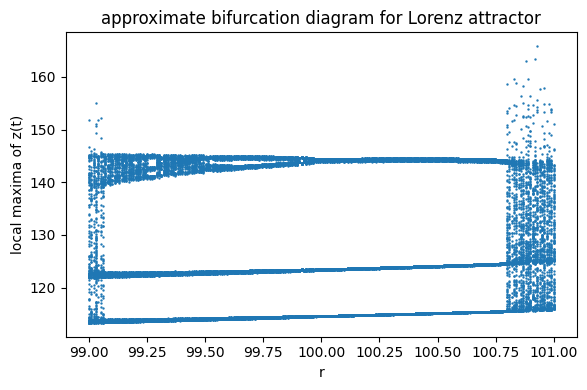

In [119]:
rs = np.linspace(99, 101, 200)
x0 = np.array([1.0, 3.0, 2.0])
r_all = []
zmax_all = []

for r in rs:
    t, x = rk4(lorenz, 0, 300, x0, dt, f_args=(sigma, r, b))
    keep = t > 250.0 # discard transient
    z = x[keep, 2]
    zmax = local_maxima(z)
    r_all.extend([r] * len(zmax))
    zmax_all.extend(zmax)

plt.figure(figsize=(6,4))
plt.scatter(r_all, zmax_all, s=0.5)
plt.xlabel('r')
plt.ylabel('local maxima of z(t)')
plt.title('approximate bifurcation diagram for Lorenz attractor')
plt.tight_layout()
plt.show()